## 1. Purpose

Workbook for the two gradient-descent-trained models (DNN and PINN, no-environment
feature set) — the sklearn/Chapman-Richards baselines already have their own results
notebook (`baseline_results.ipynb`) and this one deliberately doesn't duplicate that,
since none of the four baselines use gradient descent and so have no loss curves to
look at.

This notebook only *reads* what's already saved under `outputs/` — it never trains or
evaluates anything itself. See section 2 below for exactly which scripts to run first.

Covers **both split types** DNN/PINN can now run under:
- `temporal` — train on the earliest years, validate on 2021, test on 2023
- `spatial_block` — train/val/test are whole held-out forestry compartments

Four things this notebook is for:
1. Plotting training/validation loss curves for whichever runs exist.
2. A results table comparing DNN/PINN against the matching baseline numbers for the
   *same* split type, so a new run's metrics are always read next to the numbers
   they're actually being compared against.
3. A running record of what's been tried and what to try next.
4. Comparing the two split types against each other, once both exist.

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import plot_loss_curve
from models.common.saving import model_output_dir

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
NEURAL_MODELS = ["dnn_noenv", "pinn_noenv"]
BASELINE_MODELS = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]

# DNN/PINN never run plot_level (that was only ever the baselines' original
# sanity check), so only these two split types apply to them.
SPLIT_TYPES = ["temporal", "spatial_block"]

## 2. Which files to run, to (re)compile these results

1. **Push cleaned data to the cluster** (`data/processed/` and `data/interim/` are
   both gitignored, neither travels via git):
   - `rsync` `data/processed/master/*.parquet` to the cluster, then there run
     `python -m data_processing.export_model_tables` to regenerate
     `data/processed/current_state/` on that machine.
   - `rsync` `data/interim/plot_coordinates.csv.gz` directly (small, no need to
     regenerate) -- only needed for `spatial_block_split`; a job failing with
     `No such file or directory: .../plot_coordinates.csv.gz` means this was skipped.
2. **Fit, on the cluster (GPU)**:
   `python -m models.dnn_noenv.run_dnn_noenv --cohort <4survey|6survey> --split-type <temporal|spatial_block> --max-epochs 500`
   and the same for `models.pinn_noenv.run_pinn_noenv`. Omit `--cohort` to run both.
   `--split-type` defaults to `temporal` if omitted. This is the FIT-only step — it
   never touches the test split. Saves checkpoints, scalers, `training_history.csv`,
   `run_metadata.json` under `outputs/<split_type>/<model>/<cohort>/` (`temporal` and
   `spatial_block` are always prefixed; there is no unprefixed default for DNN/PINN,
   unlike the baselines, since DNN/PINN never run `plot_level`).
3. **Pull results back**: `rsync` `outputs/temporal/`, `outputs/spatial_block/`, and
   `outputs/run_logs/` from the cluster down to the laptop.
4. **Evaluate, locally (cheap, CPU)**:
   `python -m models.dnn_noenv.evaluate_dnn_noenv --split-type <temporal|spatial_block>`
   and the same for `models.pinn_noenv.evaluate_pinn_noenv` (omit `--cohort` for
   both). This is what actually writes the real `metrics.json`/`predictions.csv` this
   notebook reads below.

Before trusting a result read below as real: check `run_metadata.json`'s
`max_epochs` for that run wasn't a quick sanity check (see
`documentation/progress_notes.md`, "Checking a run is good, not just present").

## 3. Training / validation loss curves

One panel per model per cohort, one figure per split type. `train_loss`/`val_loss`
are always plotted; `data_loss`/`physics_loss`/`trajectory_loss` are added
automatically for the PINN (see `models/common/plotting.py::plot_loss_curve`). The
dotted vertical line marks the best epoch — the one `load_best_model()` actually
loads, not necessarily the last epoch trained.

A panel is left blank with a note if that `(model, cohort, split_type)` combination
hasn't been run yet.

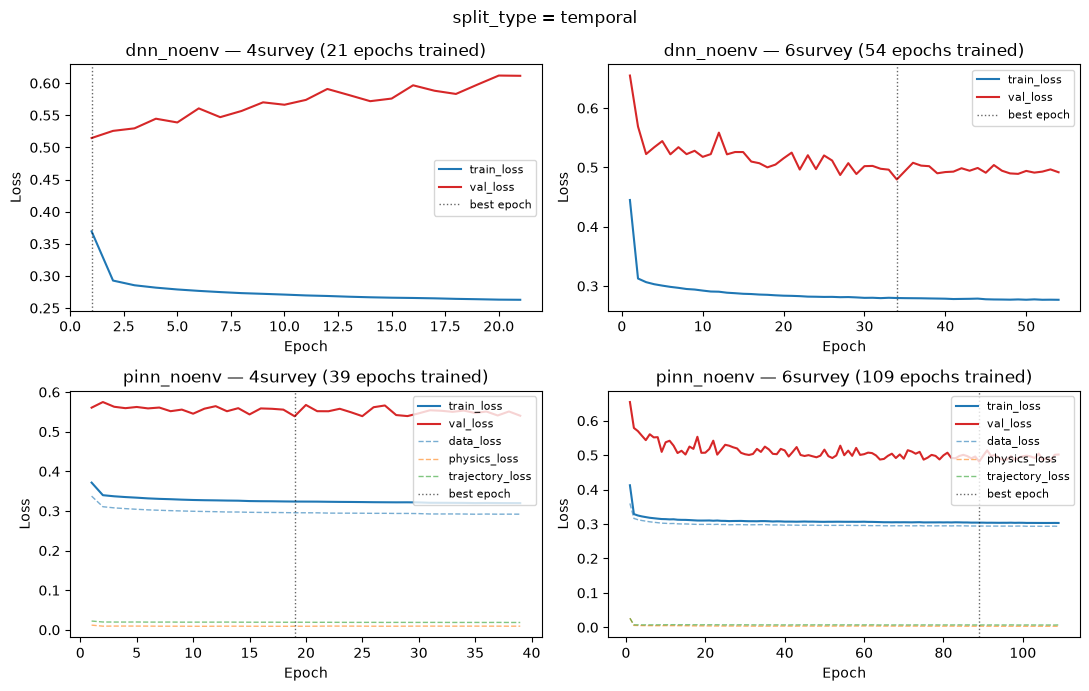

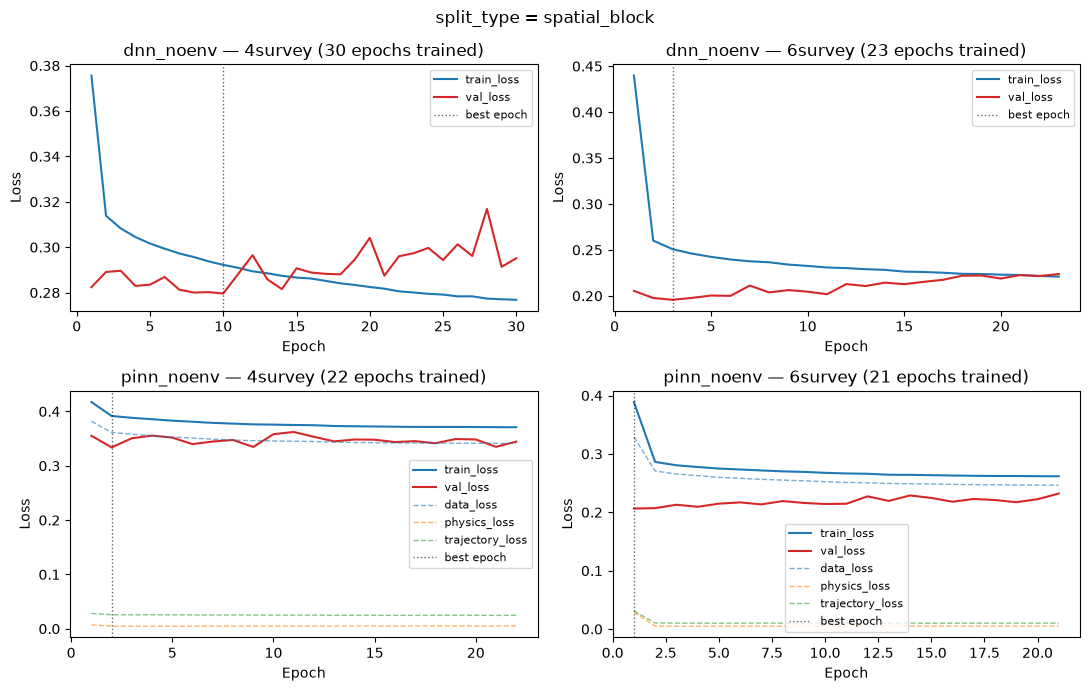

In [3]:
for split_type in SPLIT_TYPES:
    fig, axes = plt.subplots(len(NEURAL_MODELS), len(COHORTS), figsize=(11, 7))
    fig.suptitle(f"split_type = {split_type}")

    for row, model_name in enumerate(NEURAL_MODELS):
        for col, cohort in enumerate(COHORTS):
            ax = axes[row, col]
            history_path = model_output_dir(model_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                ax.set_title(f"{model_name} / {cohort} — not run yet")
                ax.axis("off")
                continue
            history_df = pd.read_csv(history_path)
            plot_loss_curve(history_df, ax=ax)
            ax.set_title(f"{model_name} — {cohort} ({len(history_df)} epochs trained)")

    fig.tight_layout()
    plt.show()

## 4. Test-set metrics: DNN/PINN vs. the matching-split-type baselines

Reads whatever `metrics.json` currently exists for each model under each split type
— real numbers once the full-length runs have been evaluated, sanity-check numbers
until then (check `run_metadata.json`'s `max_epochs` if unsure which one you're
looking at). Baselines are only compared within the *same* split type, since a
`temporal` DNN result isn't a fair comparison against a `plot_level` or
`spatial_block` baseline number.

In [4]:
def load_metrics(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


rows = []
for split_type in SPLIT_TYPES:
    for cohort in COHORTS:
        for model_name in BASELINE_MODELS + NEURAL_MODELS:
            metrics = load_metrics(model_output_dir(model_name, cohort, split_type=split_type) / "metrics.json")
            if metrics is not None:
                rows.append({"split_type": split_type, "cohort": cohort, "model": model_name, **metrics})

metrics_table = pd.DataFrame(rows)[["split_type", "cohort", "model", "mae", "rmse", "r2", "bias", "accuracy_pct"]]
metrics_table.sort_values(["split_type", "cohort", "rmse"])

,split_type,cohort,model,mae,rmse,r2,bias,accuracy_pct
16,spatial_block,4survey,dnn_noenv,3.857533,5.068559,0.601242,0.358706,80.004433
17,spatial_block,4survey,pinn_noenv,4.191261,5.486234,0.532814,0.506345,77.749063
14,spatial_block,4survey,linear_baseline,4.611554,5.816721,0.474833,-0.127076,75.485714
15,spatial_block,4survey,rf_baseline,4.534183,5.988427,0.443370,0.064402,76.444318
12,spatial_block,4survey,chapman_richards,4.867781,6.107296,0.421053,1.834744,74.990029
13,spatial_block,4survey,average_by_age,5.113634,6.347579,0.374601,2.171900,74.015856
22,spatial_block,6survey,dnn_noenv,2.541319,3.619430,0.747698,-0.314991,85.741564
23,spatial_block,6survey,pinn_noenv,2.589449,3.715292,0.734156,-0.292443,85.348694
19,spatial_block,6survey,average_by_age,2.686161,3.891533,0.708337,-0.226866,84.838055
18,spatial_block,6survey,chapman_richards,2.858532,3.966825,0.696941,0.040132,84.169889


## 5. Experiments run so far (DNN/PINN specifically)

Full detail and the reasoning chain live in `documentation/experiment_log.md`'s
Findings log — this section is a short pointer, not a duplicate.

- **Baselines under `temporal_split`** (2026-07-15): far larger degradation than under
  `spatial_block_split` — up to +141.7% RMSE for some models. Chapman-Richards (the
  physically-constrained model) degraded the *least* — the empirical motivation for
  the PINN.
- **First real DNN/PINN run** (2026-07-16, `temporal_split`): both models beat every
  temporal-split baseline, but the physics constraint doesn't win outright — a real,
  citable mixed result (DNN wins 4survey, PINN wins 6survey). Reading the loss curves
  (section 3) mattered here: DNN's 4survey `best_epoch=1` is a textbook overfitting
  climb, so its reported RMSE is closer to an untrained model's number than a
  converged one; PINN's `val_loss` on the same data stayed flat instead.
- **First real DNN/PINN run under `spatial_block_split`** (2026-07-16) -- the split
  that actually matches the dissertation's central research question. Both models
  beat every spatial-block baseline on both cohorts, and beat their own
  `temporal_split` numbers too (e.g. DNN/4survey R²=0.60 here vs 0.45 under
  temporal). This time DNN beats PINN on *both* cohorts, unlike the 1-1 split under
  temporal. Training stopped early (21-30 epochs, best epoch 1-10) -- not
  necessarily a problem: `spatial_block`'s training set spans all four survey years
  per train-plot (vs. `temporal`'s narrow 2-year 4survey set), a richer signal a
  small network can fit quickly. Not yet confirmed whether this is genuine
  convergence or an early-stopping artefact -- see section 6's tuning plan.
- **Not yet run**: any hyperparameter variant of either split (see section 6),
  `temporal_narrow_gap`, and the PINN's `cr_matched` anchor variant (see
  `experiment_log.md`'s naming glossary for what these mean).

## 6. Ideas for parameter tuning

Concrete things to check in the loss curve, and a concrete plan for the open question
from section 5 (is the fast `spatial_block` convergence genuine, or an early-stopping
artefact?) -- cheap to test, each run only takes 15-30 minutes at the current epoch
counts.

### Hyperparameter-tuning plan (next -- applies to both split types)

Widened after checking all 8 real runs, not just `spatial_block` -- **every one stops
well short of the 500-epoch budget**:

| Split | Model | Cohort | Total epochs | Best epoch | `val_loss` start→end |
|---|---|---|---|---|---|
| temporal | dnn_noenv | 4survey | 21 | 1 | 0.51 → 0.61 (**+19%, climbs**) |
| temporal | dnn_noenv | 6survey | 54 | 34 | 0.65 → 0.49 (improves, healthy) |
| temporal | pinn_noenv | 4survey | 39 | 19 | 0.56 → 0.54 (flat, healthy) |
| temporal | pinn_noenv | 6survey | 109 | 89 | 0.65 → 0.50 (improves, healthy) |
| spatial_block | dnn_noenv | 4survey | 30 | 10 | 0.28 → 0.30 (mild drift) |
| spatial_block | dnn_noenv | 6survey | 23 | 3 | 0.21 → 0.22 (mild drift) |
| spatial_block | pinn_noenv | 4survey | 22 | 2 | 0.36 → 0.34 (flat) |
| spatial_block | pinn_noenv | 6survey | 21 | 1 | 0.21 → 0.23 (mild drift) |

**DNN is the unstable one, not PINN.** DNN is bimodal -- its best case
(`temporal`/6survey) is the healthiest curve of all eight; its worst case
(`temporal`/4survey) is the single worst, a textbook overfitting collapse (+19%,
monotonic, never recovers). PINN never collapses anywhere near that badly -- its
worst drift is still smaller than DNN's best-case improvement. **Decision: focus
tuning effort on PINN going forward** -- it's the more stable model to tune from, and
the actual research contribution of this dissertation. DNN stays in purely as the
baseline comparison.

Cheapest-to-test first -- each is a single changed constant, not a redesign, and
applies to both split types:

1. **Loosen both patience knobs.** `lr_scheduler_patience=10`,
   `early_stopping_patience=20` are tight relative to how noisy `val_loss` looks
   epoch-to-epoch, and relative to a 500-epoch budget none of the eight runs came
   close to using. Try `lr_scheduler_patience=15`, `early_stopping_patience=40`.
2. **Smooth the early-stopping criterion.** A single noisy epoch currently counts
   toward the patience counter -- tracking a short moving average of `val_loss`
   (3-5 epoch window) instead of the raw per-epoch value would stop one noisy epoch
   from triggering/counting toward a stop.
3. **Increase `BATCH_SIZE`** (currently 128) for smoother, less noisy gradient
   estimates -- combined with #2, should clarify whether more training actually helps.
4. **Try SGD+Nesterov momentum as an alternate optimizer to Adam.** Not an addition
   to what's there already -- Adam already is a momentum method (β1=0.9 default
   first-moment estimate). This is a genuinely different optimizer, worth an A/B
   test after #1-3.

If none of these meaningfully change the result, that's useful evidence the current
numbers reflect genuine convergence, not premature stopping.

**Forward-looking note**: whatever fixes/improves PINN's training dynamics here (no
environmental features yet) should carry over once terrain/wind features are added
for the full Env-PINN -- same architecture, same optimizer, same loss structure, just
a wider feature set. Worth re-checking these same questions again at that point
rather than assuming they're automatically solved.

### General loss-curve diagnostics

| What to check in the loss curve | If you see this... | ...try this |
|---|---|---|
| `val_loss` vs `train_loss` gap | `val_loss` plateaus or rises early while `train_loss` keeps falling (overfitting) -- this is what happened to DNN/4survey under `temporal_split` | increase `L1_COEFFICIENT`, add dropout, or reduce `NoEnvNetwork`'s width/depth (`models/common/torch_model.py`) |
| `val_loss` shape | never really improves, both losses flat from the start (underfitting / stuck) | raise `LEARNING_RATE`, check `LR_SCHEDULER_PATIENCE`/`LR_SCHEDULER_FACTOR` aren't shrinking it too fast, or widen the network |
| best epoch vs. total trained | best epoch is very early and training runs long past it without improving | see the tuning plan above -- could be genuine fast convergence or premature stopping; test before assuming either |
| PINN's `physics_loss`/`trajectory_loss` vs `data_loss` | one term numerically dominates the combined `train_loss` | re-tune `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` (`models/pinn_noenv/pinn_noenv.py`) so no single term swamps the others |
| PINN's `physics_loss`/`trajectory_loss` going to ~0 immediately | the physics terms aren't actually constraining anything (trivially satisfied) | check they're computed against the *unscaled* CR curve correctly, and that `frozen_cr_params` in `run_metadata.json` are sensible, not degenerate |
| DNN vs PINN, same split type | PINN's test RMSE isn't better than the DNN's | not automatically a bug -- but check the loss *curves*, not just final RMSE -- DNN's "wins" so far have coincided with its overfitting cases |
| Same model, `temporal` vs. `spatial_block` | very different loss-curve shape/stability between the two splits | expected to some degree -- `spatial_block`'s training set spans all four survey years for every train-plot, `temporal`'s 4survey training set is only two years |

Also planned (see `experiment_log.md`'s "Planned robustness checks" table, not yet
triggered): `temporal_narrow_gap`, and the PINN's `cr_matched` anchor variant.